In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import json

ModuleNotFoundError: No module named 'tensorflow'

## Data

In [4]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

In [5]:
x_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

* x_train: np array of ints, where each int is mapped to a word
* y_train: np array of 

In [6]:
max([max(sequence) for sequence in x_train])

9999

In [7]:
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

x_train: (25000,), y_train: (25000,)
x_test: (25000,), y_test: (25000,)


## Decoding Reviews

In [8]:
word_index = imdb.get_word_index()
with open('word_index.json', 'w') as f:
    json.dump(word_index, f)

In [9]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

#decoding x_train
decoded_reviews_x_train = [" ".join([reverse_word_index.get(j - 3, "?") for j in i]) for i in x_train]
decoded_reviews_x_train = np.array(decoded_reviews_x_train)
decoded_reviews_x_train[0]

#decoding x_test
decoded_reviews_x_test = [" ".join([reverse_word_index.get(j - 3, "?") for j in i]) for i in x_test]
decoded_reviews_x_test = np.array(decoded_reviews_x_test)
decoded_reviews_x_train[0]

np.str_("? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don'

## Encoding the integer sequences via multi-hot encoding

In [10]:
def vectorize_sequences(sequences, dimension=10000):
    
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

x_train = vectorize_sequences(x_train)
x_test = vectorize_sequences(x_test)

In [11]:
x_train.shape

(25000, 10000)

In [12]:
y_train = np.asarray(y_train).astype("float32")
y_test = np.asarray(y_test).astype("float32")

## making cols as examples

In [13]:
x_train = x_train.T     # (10000, 25000)
x_test  = x_test.T      # (10000, 25000)

y_train = y_train.reshape(1, -1)   # (1, 25000)
y_test  = y_test.reshape(1, -1)    # (1, 25000)

In [14]:
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test{x_test.shape}, y_test: {y_test.shape}")

x_train: (10000, 25000), y_train: (1, 25000)
x_test(10000, 25000), y_test: (1, 25000)


In [15]:
x_train[:, 0]

array([0., 1., 1., ..., 0., 0., 0.], shape=(10000,))

## Model Building

In [16]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_deriv(Z):
    s = sigmoid(Z)
    return s * (1 - s)

def relu(Z):
    return np.maximum(0, Z)

def relu_deriv(Z):
    return (Z > 0).astype(float)

In [17]:
def nn_model(X, y, epochs, lr):
    n_x, m = X.shape
    n_h1 = 16   # first hidden layer size
    n_h2 = 16   # second hidden layer size
    n_y = 1    # output layer size

    # Xavier initialization
    np.random.seed(1)
    W1 = np.random.randn(n_h1, n_x) * np.sqrt(1./n_x)
    b1 = np.zeros((n_h1, 1))
    W2 = np.random.randn(n_h2, n_h1) * np.sqrt(1./n_h1)
    b2 = np.zeros((n_h2, 1))
    W3 = np.random.randn(n_y, n_h2) * np.sqrt(1./n_h2)
    b3 = np.zeros((n_y, 1))

    cost_hist = []

    for i in range(epochs):
        #Forward Pass
        Z1 = np.dot(W1, X) + b1
        A1 = relu(Z1)

        Z2 = np.dot(W2, A1) + b2
        A2 = relu(Z2)

        Z3 = np.dot(W3, A2) + b3
        print(Z3.shape)
        A3 = sigmoid(Z3)

        #Cost 
        cost = -np.mean(y * np.log(A3 + 1e-8) + (1-y) * np.log(1-A3 + 1e-8))
        cost_hist.append(cost)

        if i % 10 == 0:
            print(f"{i}th, cost={cost:.4f}")

        #Backward Pass
        dZ3 = A3 - y
        dW3 = np.dot(dZ3, A2.T) / m
        db3 = np.sum(dZ3, axis=1, keepdims=True) / m

        dA2 = np.dot(W3.T, dZ3)
        dZ2 = dA2 * relu_deriv(Z2)
        dW2 = np.dot(dZ2, A1.T) / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m

        dA1 = np.dot(W2.T, dZ2)
        dZ1 = dA1 * relu_deriv(Z1)
        dW1 = np.dot(dZ1, X.T) / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m

        #Update
        W3 -= lr * dW3
        b3 -= lr * db3
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return W1, b1, W2, b2, W3, b3, cost_hist


In [18]:
epochs, lr = 1000, 0.1
W1, b1, W2, b2, W3, b3, cost_hist = nn_model(x_train, y_train, epochs, lr)

(1, 25000)
0th, cost=0.6932
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
10th, cost=0.6751
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
20th, cost=0.6407
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
30th, cost=0.6116
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
40th, cost=0.5835
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
50th, cost=0.5548
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
60th, cost=0.5309
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
70th, cost=0.5174
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)
(1, 25000)

KeyboardInterrupt: 

In [19]:
 # After the training loop
np.savez_compressed('./model_params.npz', W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

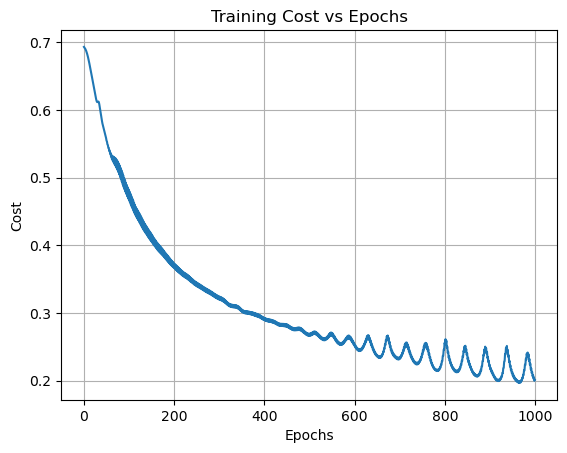

In [16]:
plt.plot(range(epochs), cost_hist)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Training Cost vs Epochs")
plt.grid(True)
plt.show()

In [17]:
def predict(X, W1, b1, W2, b2, W3, b3):
    
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)
    
    return (A3 > 0.5).astype(int), A3

preds_test, proba_test = predict(x_test, W1, b1, W2, b2, W3, b3)
accuracy_test = np.mean(preds_test == y_test) * 100

preds_train, proba_train = predict(x_train, W1, b1, W2, b2, W3, b3)
accuracy_train = np.mean(preds_train == y_train) * 100

print(f"Accuracy on Test Data: {accuracy_test}%")
print(f"Accuracy on Train Data: {accuracy_train}%")

Accuracy on Test Data: 87.012%
Accuracy on Train Data: 92.192%


In [19]:
predict(x_test[:, 2].reshape(-1, 1), W1, b1, W2, b2, W3, b3)

NameError: name 'predict' is not defined

In [ ]:
x_test[:, 2]

np.float32(1.0)

array([[0.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(10000, 1))